In [1]:
import sys
sys.path.append('../scripts')

from analysis import load_runmap, load_baselines, load_metadata
from plotting import (
    plot_run, plot_all_runs, plot_mean_run,
    plot_mean_across_subjects, plot_subjects_side_by_side,
)

runmap_df = load_runmap()
baselines_df = load_baselines()
metadata_df = load_metadata()
runmap_df.shape, baselines_df.shape, metadata_df.shape

((24200, 6), (968, 5), (62, 5))

## Raw SSVEP maps -- MET000, session 1

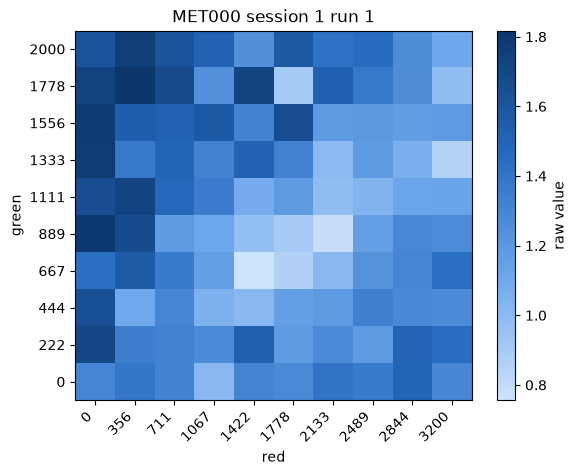

In [2]:
plot_run(runmap_df, baselines_df, 'MET000', 1, run=1);

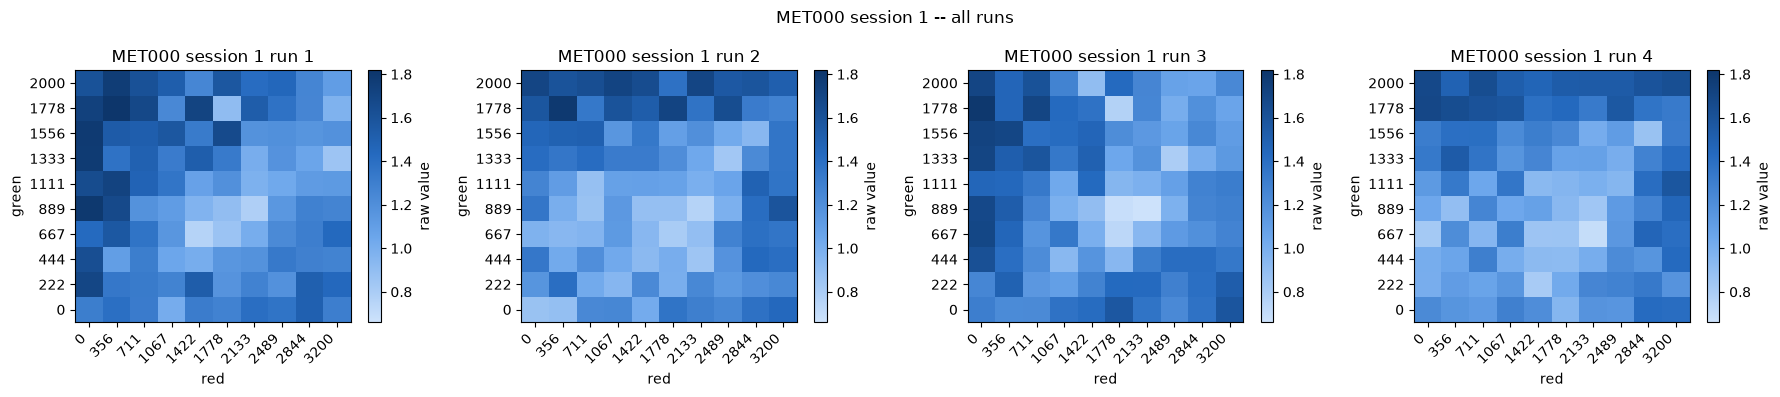

In [3]:
plot_all_runs(runmap_df, baselines_df, 'MET000', 1);

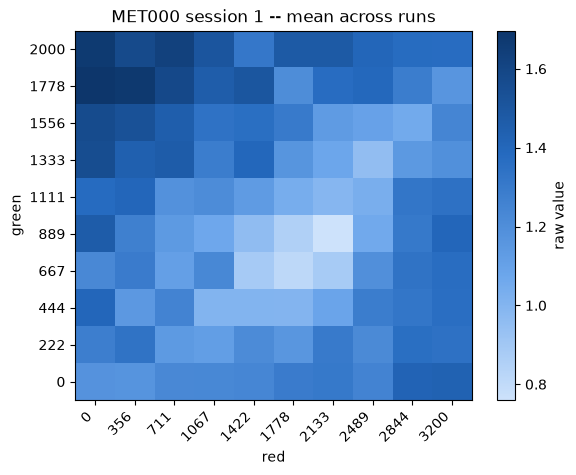

In [4]:
plot_mean_run(runmap_df, baselines_df, 'MET000', 1);

## Ragged session (3 runs) -- MET037, group PD
`plot_all_runs` reads the run count from the data, so 3-run sessions plot fine.

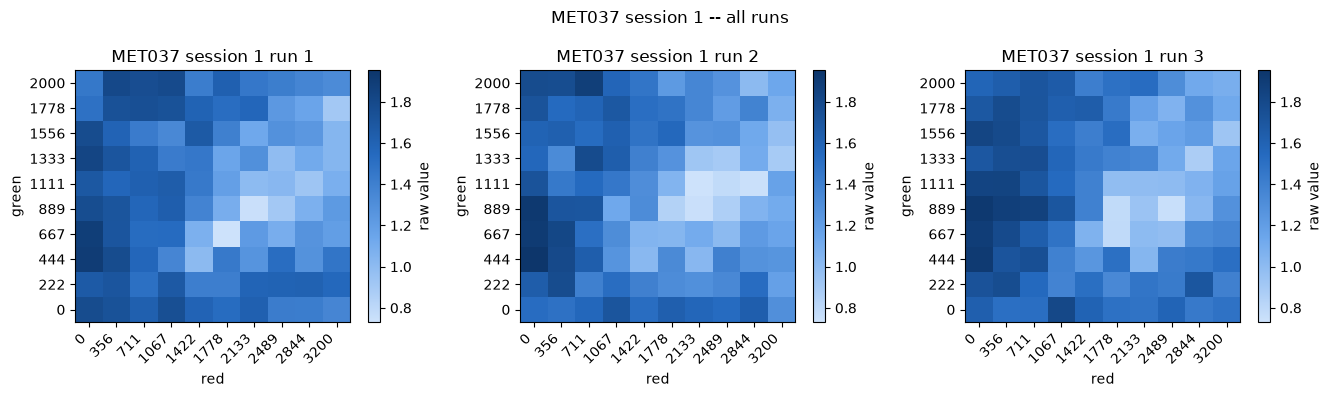

In [5]:
plot_all_runs(runmap_df, baselines_df, 'MET037', 1);

## Baseline-normalized maps
`normalize` is a dict of `scope` (`'run'` or `'session'`), `trials` (`'all'` / `'first2'` (pre-grid) / `'last2'` (post-grid)), and `method` (`'percent'` / `'db'` / `'zscore'`). Same plot functions as above -- just feed them raw or normalized.

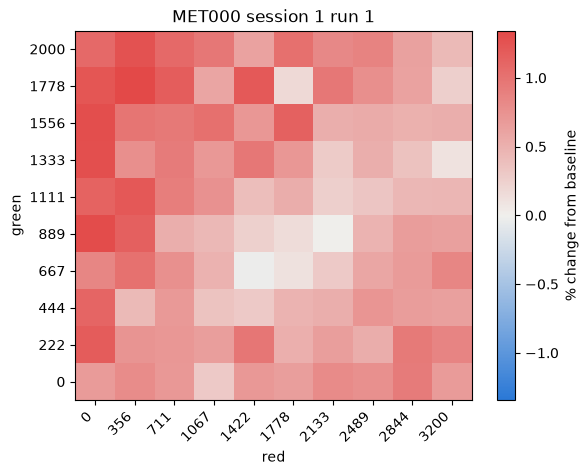

In [6]:
plot_run(
    runmap_df, baselines_df, 'MET000', 1, run=1,
    normalize={'scope': 'run', 'trials': 'all', 'method': 'percent'},
);

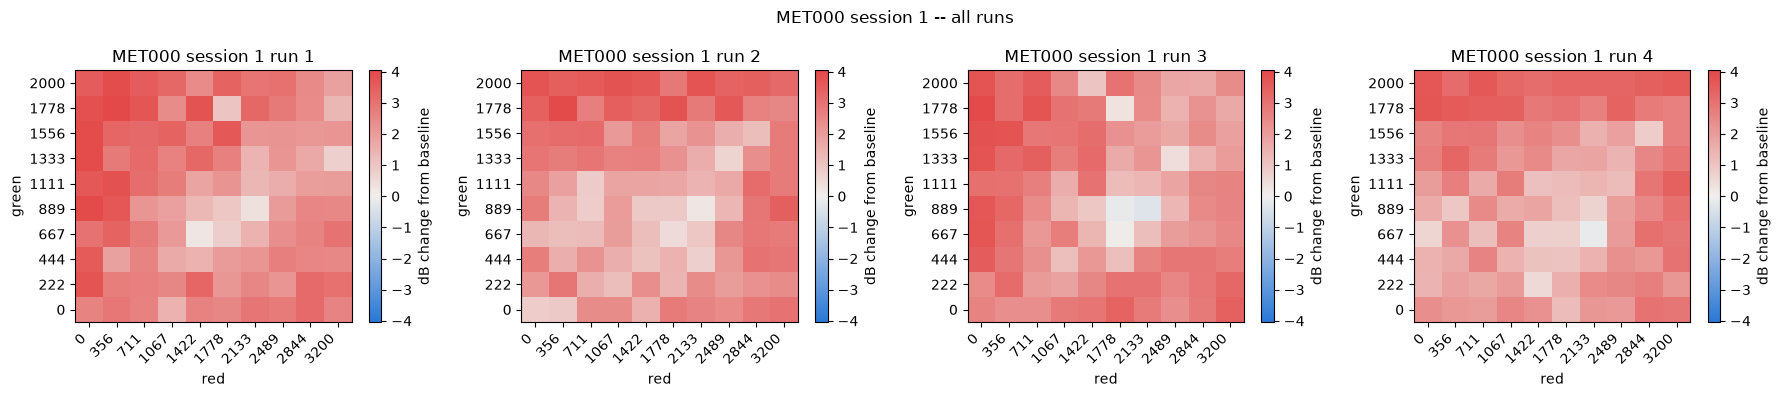

In [7]:
plot_all_runs(
    runmap_df, baselines_df, 'MET000', 1,
    normalize={'scope': 'session', 'trials': 'first2', 'method': 'db'},
);

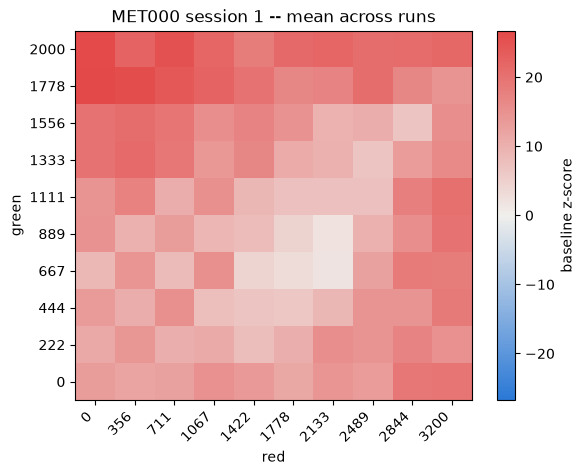

In [8]:
plot_mean_run(
    runmap_df, baselines_df, 'MET000', 1,
    normalize={'scope': 'run', 'trials': 'last2', 'method': 'zscore'},
);

## Color limits and colormap overrides
Every plot function takes optional `clim=(vmin, vmax)` and `cmap=`. `plot_all_runs` and the side-by-side functions below share one color scale across all their panels by default (auto-computed from all the data being shown, unless `clim` is given).

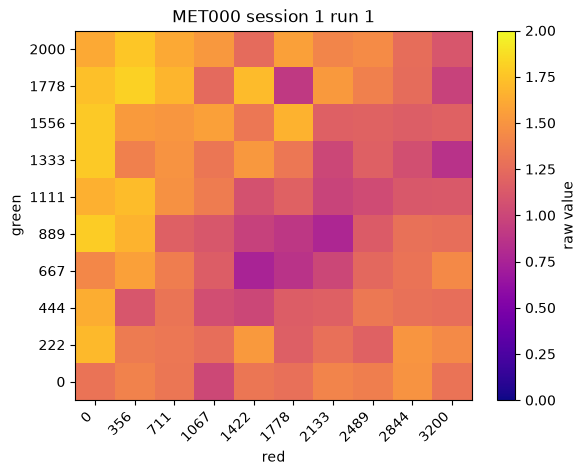

In [9]:
plot_run(runmap_df, baselines_df, 'MET000', 1, run=1, clim=(0, 2), cmap='plasma');

## Mean across subjects
`plot_mean_across_subjects` takes each subject's own mean-across-runs grid, then averages those across subjects (one session at a time, so 2-session subjects aren't double-counted). No filter = every subject.

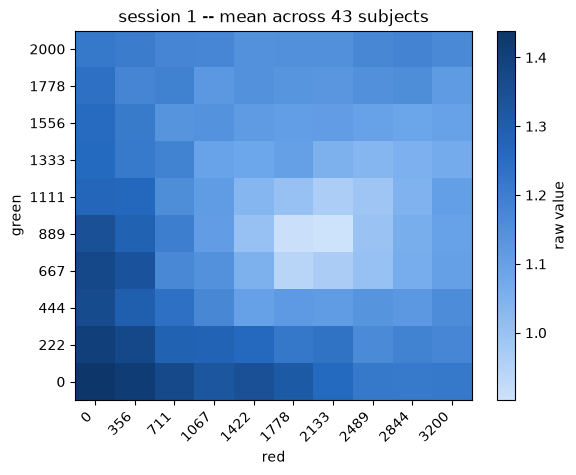

In [10]:
plot_mean_across_subjects(runmap_df, baselines_df, metadata_df, session=1);

Same principle, restricted to one group:

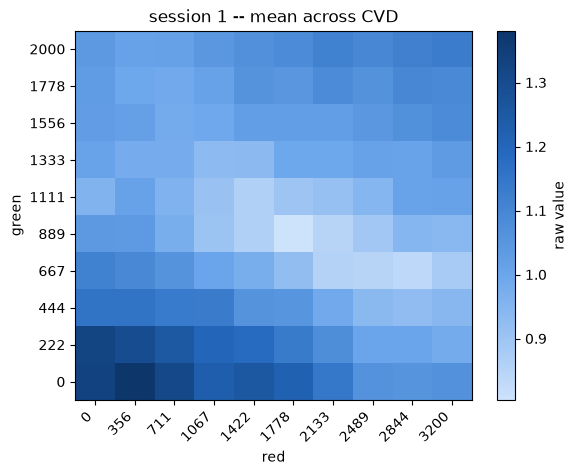

In [13]:
plot_mean_across_subjects(runmap_df, baselines_df, metadata_df, session=1, group='CVD');

## Subjects side by side
One heatmap per subject (each subject's own mean-across-runs grid), sharing one color scale. Filter by group/subgroup, or pass an explicit `sub_ids` list.

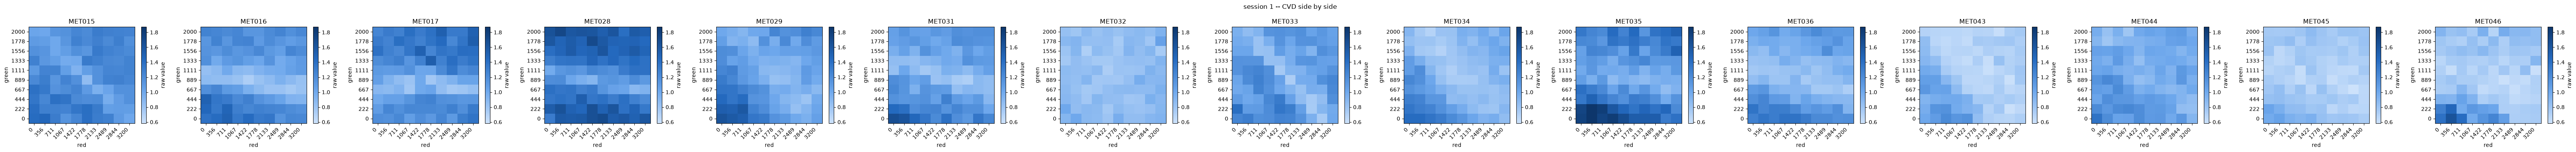

In [12]:
plot_subjects_side_by_side(runmap_df, baselines_df, metadata_df, session=1, group='CVD');

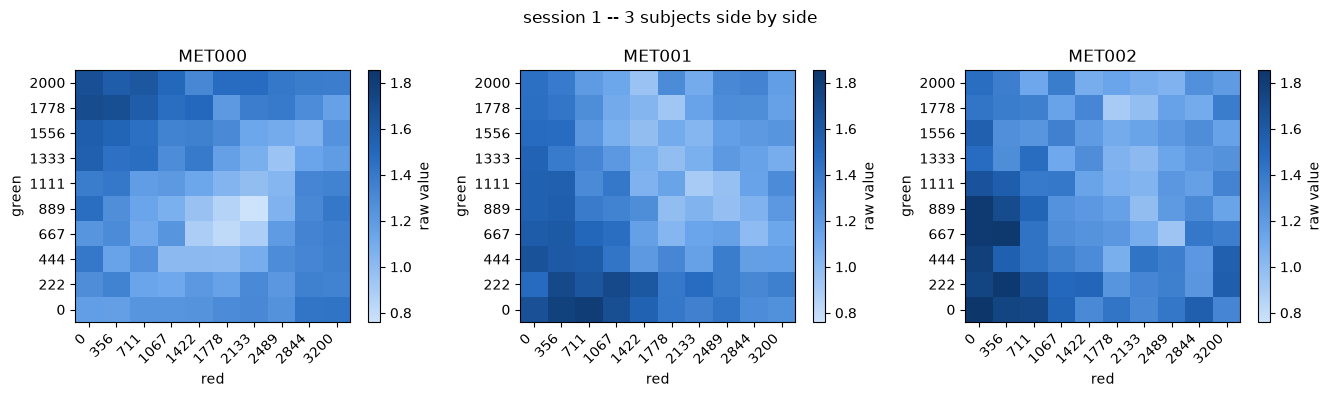

In [14]:
plot_subjects_side_by_side(
    runmap_df, baselines_df, metadata_df, session=1,
    sub_ids=['MET000', 'MET001', 'MET002'],
);

Aggregate functions also take `normalize`, `clim`, and `cmap`, same as the single-subject plots:

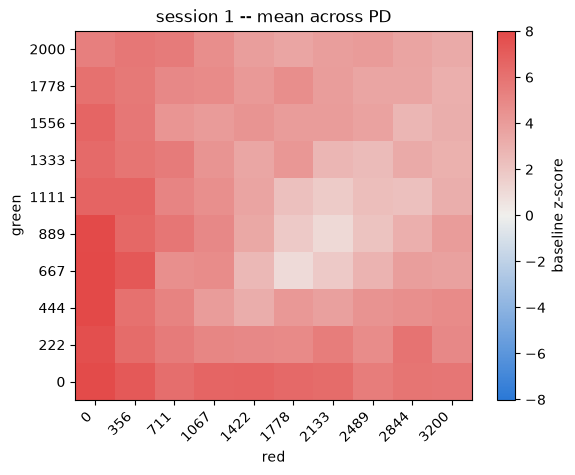

In [15]:
plot_mean_across_subjects(
    runmap_df, baselines_df, metadata_df, session=1, group='PD',
    normalize={'scope': 'session', 'trials': 'all', 'method': 'zscore'},
);